**Exploración de Datos (EDA) — Pobreza Multidimensional**

Proyecto: Modelamiento Predictivo de la Pobreza Multidimensional en Colombia
Curso: Inteligencia Artificial con Aplicaciones en Economía I
Universidad Externado de Colombia
Integrantes: Camilo Rendón, Nicolás Cubillos, Talia Linares, Alejandro Velandia


**Objetivo de esta sección**

Esta sección tiene como propósito realizar un Análisis Exploratorio de Datos (EDA) sobre la Encuesta Longitudinal Colombiana (ELCA), con el fin de:

Comprender la distribución de la pobreza multidimensional construida
Identificar patrones y relaciones entre variables socioeconómicas
Detectar variables relevantes para el modelo predictivo
Validar la coherencia económica del indicador de pobreza

**Contexto metodológico**

Dado que la ELCA no incluye directamente una medida de pobreza multidimensional, se construyó un indicador basado en la identificación de privaciones en distintas dimensiones del bienestar, siguiendo la metodología propuesta en el boletín del CEDE.

Cada privación se codifica como una variable binaria (1 = privación, 0 = no privación), y se define como pobre multidimensional a aquellos individuos que superan un umbral determinado de carencias.

**En esta sección se analiza:**
Distribución de la variable de pobreza multidimensional.
 Relación entre pobreza y variables clave:
Educación,
Ingreso,
Empleo,
Zona (urbano/rural),
Acceso a servicios básicos,
Correlaciones entre variables y la
Identificación de posibles predictores para el modelo

In [1]:
# Montar Google Drive en Colab
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive montado correctamente')

Mounted at /content/drive
Google Drive montado correctamente


In [2]:
# Instalación de librería para leer archivos Stata (.dta)
!pip install pyreadstat --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.9 MB/s eta 0:00:00


In [3]:
# Configuración general de visualización
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [4]:
path = '/content/drive/MyDrive/Proyecto'



In [5]:
os.chdir(path)


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Proyecto/base_final_modelo.csv')

# Verificación inicial de los datos

In [7]:
# Ver primeras filas
df.head()

,transicion,par_ondas,id_hogar,ola,zona,region,estrato,t_hogar,t_personas,ordeninforma,tipo_vivienda,material_pisos,material_paredes,sp_energia,sp_estrato,sp_gasnatural,sp_acueducto,sp_alcantarillado,sp_telefono,sp_recoleccion_basura,eliminan_basura,t_hogares,uc_fabricas,uc_basureros,uc_plaza_mercado,...,retpag_pub,retpag_salud,retpag_educ,retpag_arren,retpag_almac,retpag_compra,retpag_tend,retpag_efinan,proviene_2010,fhog_2013,fexhog_2013,fhog_2010,fexhog_2010,tercil2013,hacinamiento,hacinamiento_critico,indice_activos,tasa_dependencia_proxy,privacion_vivienda,priv_educacion,priv_ninez,priv_salud,priv_vivienda,ipm_sintetico,pobre_ipm
0,0,2010_2013,111001,1,1,3.00,2.00,1.00,3,1.00,0,2,2,3,2.00,3,3,3,3,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,12.00,0.07,0,0,0,0,0,0.00,0
1,0,2010_2013,111003,1,1,3.00,2.00,1.00,6,1.00,1,2,2,3,2.00,3,3,3,1,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,13.00,0.13,0,0,0,0,0,0.00,0
2,2,2010_2013,111004,1,1,3.00,2.00,2.00,4,1.00,0,3,2,3,2.00,3,3,3,3,3,3,2,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,2.00,0,6.00,0.09,0,0,0,0,0,0.00,0
3,0,2010_2013,111006,1,1,3.00,2.00,1.00,3,1.00,0,2,2,3,2.00,1,3,3,3,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,3.00,0,12.00,0.07,0,0,0,0,0,0.00,0
4,1,2010_2013,111008,1,1,3.00,2.00,1.00,3,2.00,0,3,2,3,2.00,3,3,3,1,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,10.00,0.07,0,0,0,0,0,0.00,0


In [8]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16957 entries, 0 to 16956
Columns: 178 entries, transicion to pobre_ipm
dtypes: float64(105), int64(71), object(2)
memory usage: 23.0+ MB


In [9]:
# Estadísticas descriptivas
df.describe()

,transicion,id_hogar,ola,zona,region,estrato,t_hogar,t_personas,ordeninforma,tipo_vivienda,material_pisos,material_paredes,sp_energia,sp_estrato,sp_gasnatural,sp_acueducto,sp_alcantarillado,sp_telefono,sp_recoleccion_basura,eliminan_basura,t_hogares,uc_fabricas,uc_basureros,uc_plaza_mercado,uc_terminal_bus,...,retpag_pub,retpag_salud,retpag_educ,retpag_arren,retpag_almac,retpag_compra,retpag_tend,retpag_efinan,proviene_2010,fhog_2013,fexhog_2013,fhog_2010,fexhog_2010,tercil2013,hacinamiento,hacinamiento_critico,indice_activos,tasa_dependencia_proxy,privacion_vivienda,priv_educacion,priv_ninez,priv_salud,priv_vivienda,ipm_sintetico,pobre_ipm
count,"16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00",...,"16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00","16,957.00"
mean,1.23,"8,103,137.73",1.48,0.51,5.19,2.02,1.04,4.44,1.22,0.91,2.86,1.69,2.48,1.88,1.27,2.12,1.52,1.03,1.58,2.53,1.09,0.03,0.01,0.03,0.01,...,0.06,0.00,0.01,0.01,0.00,0.01,0.03,0.02,0.23,416.01,0.84,352.44,0.85,1.99,2.26,0.14,12.40,0.10,0.41,0.10,0.00,0.38,0.41,0.22,0.39
std,1.31,"8,680,916.85",0.50,0.50,2.40,0.60,0.28,2.00,0.51,0.53,1.51,1.55,0.57,0.72,1.06,0.93,1.13,1.02,1.11,0.80,0.46,0.18,0.11,0.17,0.12,...,0.24,0.06,0.08,0.08,0.05,0.08,0.17,0.12,0.42,"1,936.17",1.09,"1,460.64",0.97,0.56,1.17,0.34,6.47,0.06,0.49,0.30,0.00,0.49,0.49,0.25,0.49
min,0.00,"111,001.00",1.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.74,0.01,2.74,0.01,1.00,0.25,0.00,2.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,"163,650.00",1.00,0.00,4.00,2.00,1.00,3.00,1.00,1.00,2.00,1.00,2.00,1.00,0.00,2.00,1.00,0.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0.00,7.00,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,"223,601.00",1.00,1.00,6.00,2.00,1.00,4.00,1.00,1.00,3.00,1.00,3.00,2.00,1.00,2.00,1.00,1.00,2.00,3.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,2.00,0.00,12.00,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3.00,"16,314,701.00",2.00,1.00,7.00,2.00,1.00,5.00,1.00,1.00,3.00,2.00,3.00,2.00,2.00,3.00,3.00,2.00,3.00,3.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,2.67,0.00,16.00,0.12,1.00,0.00,0.00,1.00,1.00,0.50,1.00
max,3.00,"22,662,701.00",2.00,1.00,10.00,4.00,8.00,39.00,12.00,5.00,6.00,8.00,3.00,6.00,3.00,3.00,3.00,3.00,3.00,5.00,23.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,"123,722.45",71.15,"41,569.09",28.34,3.00,15.00,1.00,45.00,2.33,1.00,1.00,0.00,1.00,1.00,0.75,1.00


In [10]:
df.columns

Index(['transicion', 'par_ondas', 'id_hogar', 'ola', 'zona', 'region',
       'estrato', 't_hogar', 't_personas', 'ordeninforma',
       ...
       'hacinamiento_critico', 'indice_activos', 'tasa_dependencia_proxy',
       'privacion_vivienda', 'priv_educacion', 'priv_ninez', 'priv_salud',
       'priv_vivienda', 'ipm_sintetico', 'pobre_ipm'],
      dtype='object', length=178)

Variable objetivo

In [11]:
df['pobre_ipm'].value_counts()

,count
pobre_ipm,
0,10345
1,6612


In [12]:
df['pobre_ipm'].value_counts(normalize=True)

,proportion
pobre_ipm,
0,0.61
1,0.39


/tmp/ipykernel_38410/29336354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='pobre_ipm', data=df, palette='viridis')
/tmp/ipykernel_38410/29336354.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Pobre', 'Pobre'])


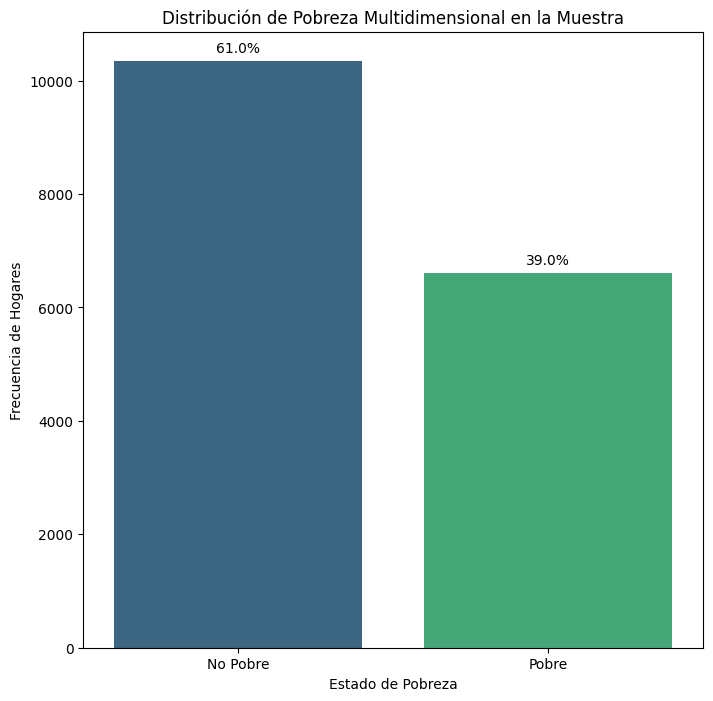

In [13]:
plt.figure(figsize=(8, 8))
ax = sns.countplot(x='pobre_ipm', data=df, palette='viridis')
ax.set_xticklabels(['No Pobre', 'Pobre'])
plt.title('Distribución de Pobreza Multidimensional en la Muestra')
plt.xlabel('Estado de Pobreza')
plt.ylabel('Frecuencia de Hogares')

# Añadir el porcentaje sobre las barras (esto demuestra dominio técnico)
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df):.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

In [14]:
# --- DIMENSIÓN EDUCACIÓN ---
# grado_educ < 3 = sin básica primaria completa
df['priv_educacion'] = (
    pd.to_numeric(df['grado_educ'], errors='coerce').fillna(0) < 3
).astype(int)

# --- DIMENSIÓN VIVIENDA ---
# material_pisos en mal estado (4=madera burda, 5=tierra)
df['priv_material'] = (
    pd.to_numeric(df['material_pisos'], errors='coerce').isin([4, 5])
).astype(int)

# Hacinamiento crítico (ya existe)
df['priv_hacinamiento'] = df['hacinamiento_critico'].fillna(0).astype(int)

# --- DIMENSIÓN SERVICIOS PÚBLICOS ---
# Sin acueducto (2 = No)
df['priv_agua'] = (
    pd.to_numeric(df['sp_acueducto'], errors='coerce') == 2
).astype(int)

# Sin alcantarillado (2 = No)
df['priv_saneamiento'] = (
    pd.to_numeric(df['sp_alcantarillado'], errors='coerce') == 2
).astype(int)

# --- CONSTRUIR IPM ---
dims = ['priv_educacion', 'priv_material',
        'priv_hacinamiento', 'priv_agua', 'priv_saneamiento']

df['ipm_sintetico'] = df[dims].mean(axis=1)
df['pobre_ipm']     = (df['ipm_sintetico'] >= 0.33).astype(int)

# --- VERIFICACIÓN ---
print("Privación promedio por dimensión:")
for d in dims:
    print(f"  {d:<25} {df[d].mean()*100:.1f}%")

print("\nProporción pobreza IPM por onda:")
print(df.groupby('par_ondas')['pobre_ipm'].mean().round(3))

print("\nDistribución pobre_ipm:")
print(df['pobre_ipm'].value_counts())

if 'riqueza_pca' in df.columns:
    corr = df['riqueza_pca'].corr(df['ipm_sintetico'])
    print(f"\nCorrelación riqueza vs IPM: {corr:.3f}")

Privación promedio por dimensión:
  priv_educacion            10.2%
  priv_material             3.7%
  priv_hacinamiento         13.5%
  priv_agua                 38.5%
  priv_saneamiento          23.3%

Proporción pobreza IPM por onda:
par_ondas
2010_2013   0.03
2013_2016   0.61
Name: pobre_ipm, dtype: float64

Distribución pobre_ipm:
pobre_ipm
0    11789
1     5168
Name: count, dtype: int64

Correlación riqueza vs IPM: 0.025


In [15]:
df

,transicion,par_ondas,id_hogar,ola,zona,region,estrato,t_hogar,t_personas,ordeninforma,tipo_vivienda,material_pisos,material_paredes,sp_energia,sp_estrato,sp_gasnatural,sp_acueducto,sp_alcantarillado,sp_telefono,sp_recoleccion_basura,eliminan_basura,t_hogares,uc_fabricas,uc_basureros,uc_plaza_mercado,...,retpag_almac,retpag_compra,retpag_tend,retpag_efinan,proviene_2010,fhog_2013,fexhog_2013,fhog_2010,fexhog_2010,tercil2013,hacinamiento,hacinamiento_critico,indice_activos,tasa_dependencia_proxy,privacion_vivienda,priv_educacion,priv_ninez,priv_salud,priv_vivienda,ipm_sintetico,pobre_ipm,priv_material,priv_hacinamiento,priv_agua,priv_saneamiento
0,0,2010_2013,111001,1,1,3.00,2.00,1.00,3,1.00,0,2,2,3,2.00,3,3,3,3,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,12.00,0.07,0,0,0,0,0,0.00,0,0,0,0,0
1,0,2010_2013,111003,1,1,3.00,2.00,1.00,6,1.00,1,2,2,3,2.00,3,3,3,1,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,13.00,0.13,0,0,0,0,0,0.00,0,0,0,0,0
2,2,2010_2013,111004,1,1,3.00,2.00,2.00,4,1.00,0,3,2,3,2.00,3,3,3,3,3,3,2,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,2.00,0,6.00,0.09,0,0,0,0,0,0.00,0,0,0,0,0
3,0,2010_2013,111006,1,1,3.00,2.00,1.00,3,1.00,0,2,2,3,2.00,1,3,3,3,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,3.00,0,12.00,0.07,0,0,0,0,0,0.00,0,0,0,0,0
4,1,2010_2013,111008,1,1,3.00,2.00,1.00,3,2.00,0,3,2,3,2.00,3,3,3,1,3,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,19.32,0.70,19.32,0.71,2.00,1.50,0,10.00,0.07,0,0,0,0,0,0.00,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16952,0,2013_2016,22628601,2,0,7.00,2.00,1.00,2,1.00,1,3,0,2,2.00,0,2,0,0,0,2,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,5.21,0.62,5.21,0.63,3.00,2.00,0,14.00,0.03,1,1,0,1,1,0.40,1,0,0,1,0
16953,0,2013_2016,22628701,2,0,7.00,2.00,1.00,5,1.00,1,3,7,2,2.00,0,0,0,0,0,1,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,5.21,0.62,5.21,0.63,2.00,2.50,0,15.00,0.12,0,0,0,0,0,0.00,0,0,0,0,0
16954,0,2013_2016,22628801,2,0,7.00,2.00,1.00,3,1.00,1,3,1,2,3.00,0,2,0,0,2,3,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,5.21,0.62,5.21,0.63,3.00,1.50,0,16.00,0.11,1,0,0,1,1,0.20,0,0,0,1,0
16955,0,2013_2016,22628901,2,0,7.00,2.00,1.00,4,1.00,1,3,0,2,2.00,0,2,0,0,0,4,1,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,5.21,0.62,5.21,0.63,3.00,1.33,0,20.00,0.06,1,0,0,1,1,0.20,0,0,0,1,0


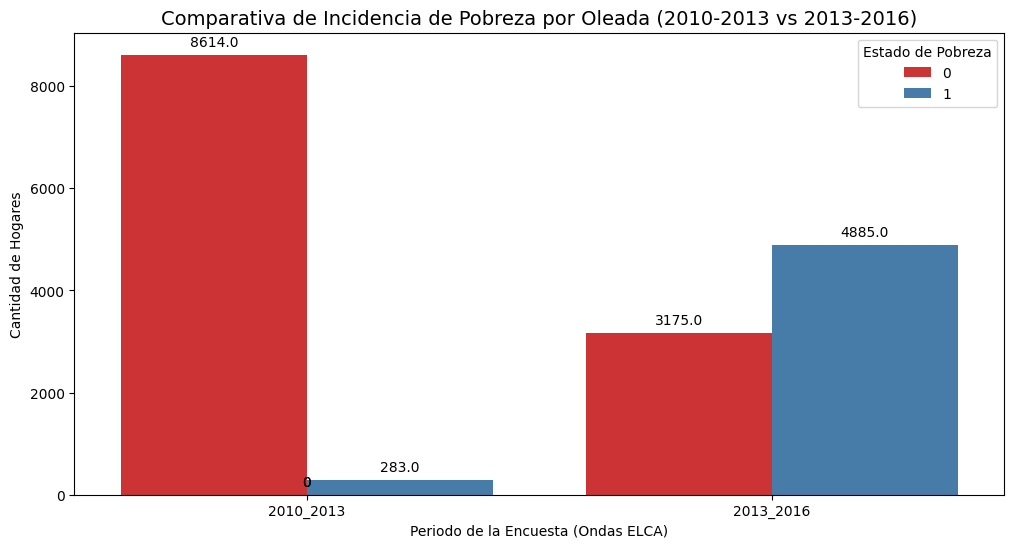

In [16]:
# Gráfica que muestra la distribución de pobreza por oleadas

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='par_ondas', hue='pobre_ipm', data=df, palette='Set1')

plt.title('Comparativa de Incidencia de Pobreza por Oleada (2010-2013 vs 2013-2016)', fontsize=14)
plt.xlabel('Periodo de la Encuesta (Ondas ELCA)')
plt.ylabel('Cantidad de Hogares')
plt.legend(title='Estado de Pobreza')

# Añadir porcentajes para ver si la pobreza subió o bajó
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

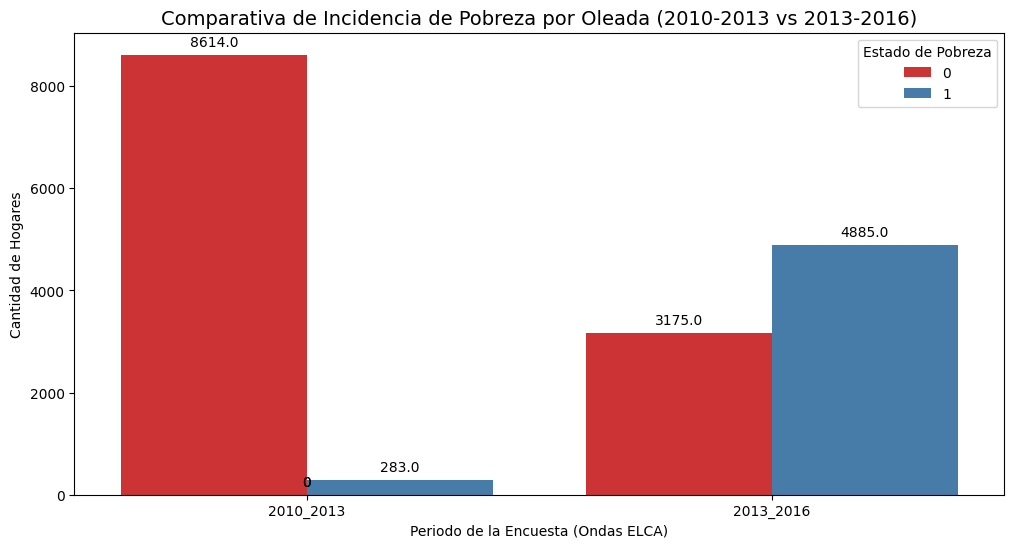

In [17]:
df['pobre_label'] = df['pobre_ipm'].map({0: 'No Pobre', 1: 'Pobre'})

# Ahora sí corre el código de la gráfica
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='par_ondas', hue='pobre_ipm', data=df, palette='Set1')

plt.title('Comparativa de Incidencia de Pobreza por Oleada (2010-2013 vs 2013-2016)', fontsize=14)
plt.xlabel('Periodo de la Encuesta (Ondas ELCA)')
plt.ylabel('Cantidad de Hogares')
plt.legend(title='Estado de Pobreza')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

In [18]:
df.groupby('par_ondas')['ipm_sintetico'].describe()

,count,mean,std,min,25%,50%,75%,max
par_ondas,,,,,,,,
2010_2013,"8,897.00",0.06,0.10,0.00,0.00,0.00,0.20,0.60
2013_2016,"8,060.00",0.31,0.16,0.00,0.20,0.40,0.40,0.80


Indice sintetico

Privaciones

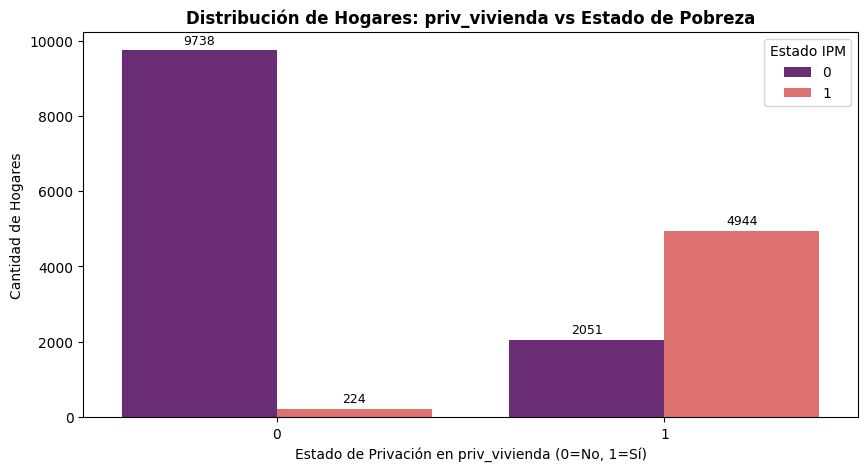

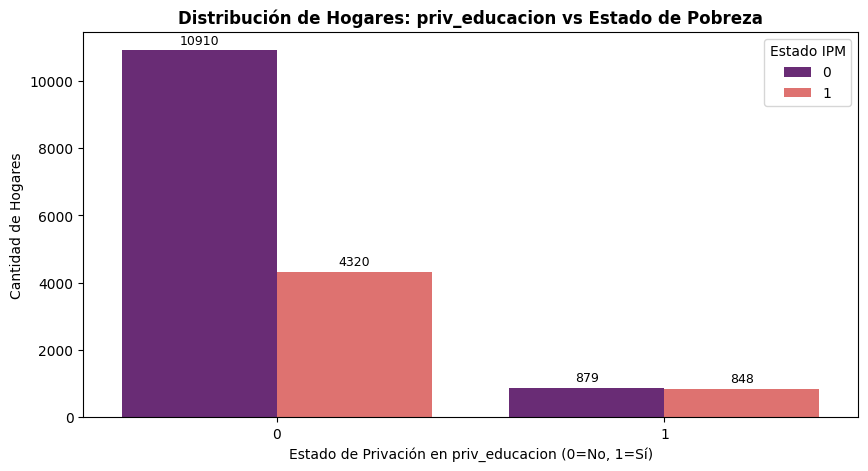

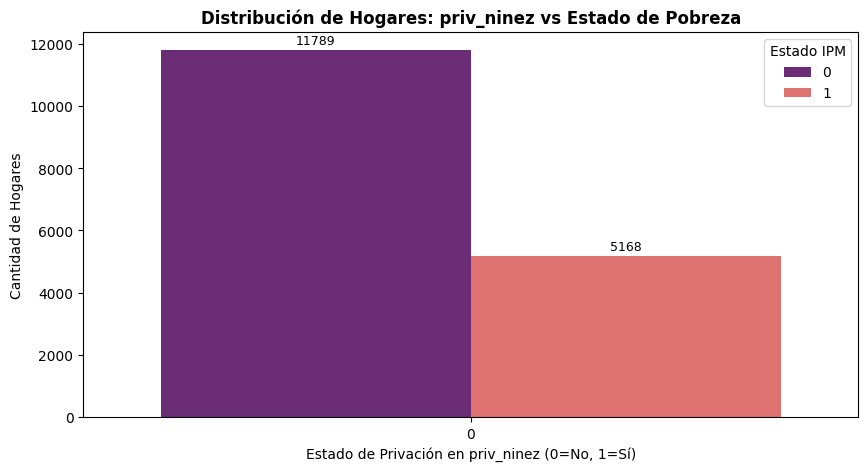

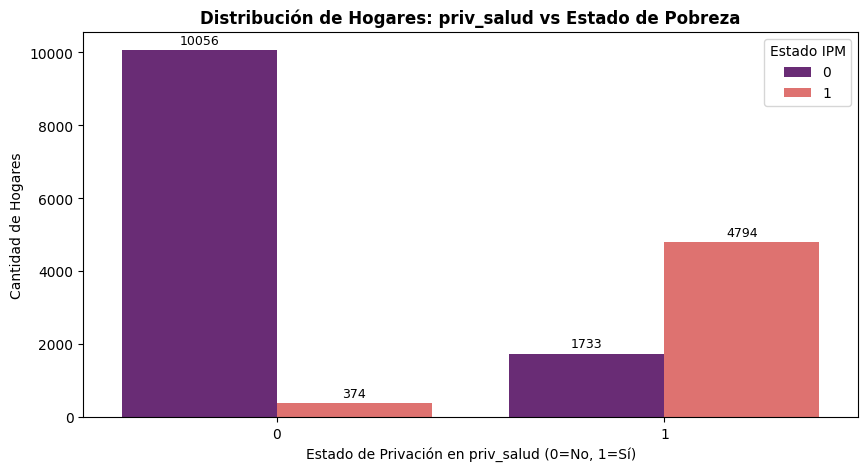

In [20]:
#Relacion con la privacion de vivienda, educacion, niñez y en salud
import matplotlib.pyplot as plt
import seaborn as sns

priv_vars = ['priv_vivienda', 'priv_educacion', 'priv_ninez', 'priv_salud']

for var in priv_vars:
    plt.figure(figsize=(10, 5))

    # Usamos countplot con hue para ver el cruce real
    ax = sns.countplot(data=df, x=var, hue='pobre_ipm', palette='magma')

    plt.title(f'Distribución de Hogares: {var} vs Estado de Pobreza', fontweight='bold')
    plt.xlabel(f'Estado de Privación en {var} (0=No, 1=Sí)')
    plt.ylabel('Cantidad de Hogares')
    plt.legend(title='Estado IPM')

    # Añadimos las etiquetas de conteo sobre las barras para que nada sea "invisible"
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=9)

    plt.show()

In [21]:
df['priv_ninez'].value_counts()

,count
priv_ninez,
0,16957


Variables Estructurales

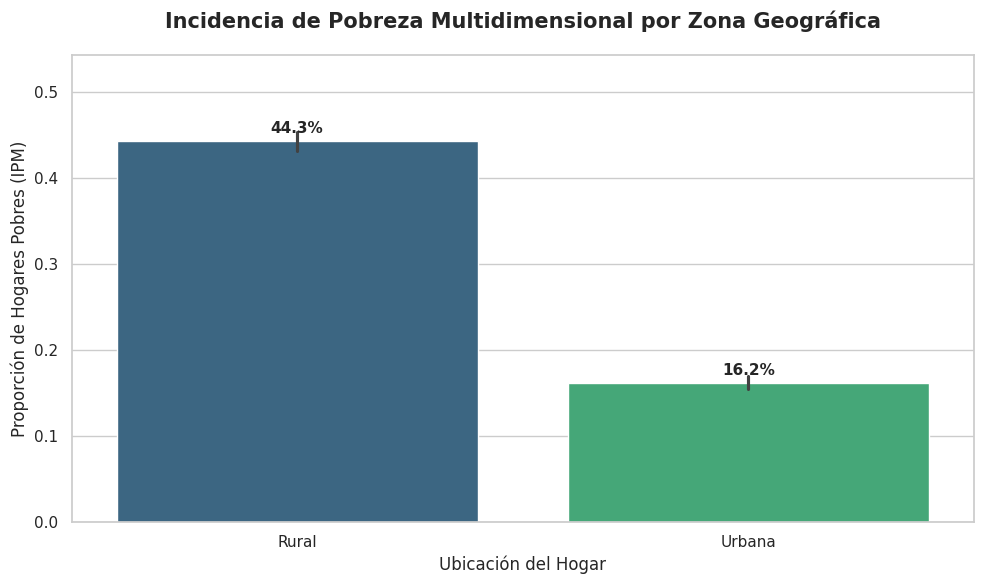

In [22]:
# Incidencia por zona (rural-urbana)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Mapeamos los nombres para que no aparezcan 0 y 1
nombres_zona = {0: 'Urbana', 1: 'Rural'}
df['zona_label'] = df['zona'].map(nombres_zona)

# 2. Creación de la gráfica
# Usamos un color distintivo para cada zona y quitamos la barra de error si no es necesaria (ci=None)
ax = sns.barplot(x='zona_label', y='pobre_ipm', data=df, palette='viridis', hue='zona_label', legend=False)

# 3. Personalización de Títulos y Ejes
plt.title('Incidencia de Pobreza Multidimensional por Zona Geográfica', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Ubicación del Hogar', fontsize=12)
plt.ylabel('Proporción de Hogares Pobres (IPM)', fontsize=12)

# 4. El "Toque de Oro": Añadir porcentajes sobre las barras
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Ajustar límites para que el texto no se corte
plt.ylim(0, df.groupby('zona')['pobre_ipm'].mean().max() + 0.1)

plt.tight_layout()
plt.show()

variables del hogar

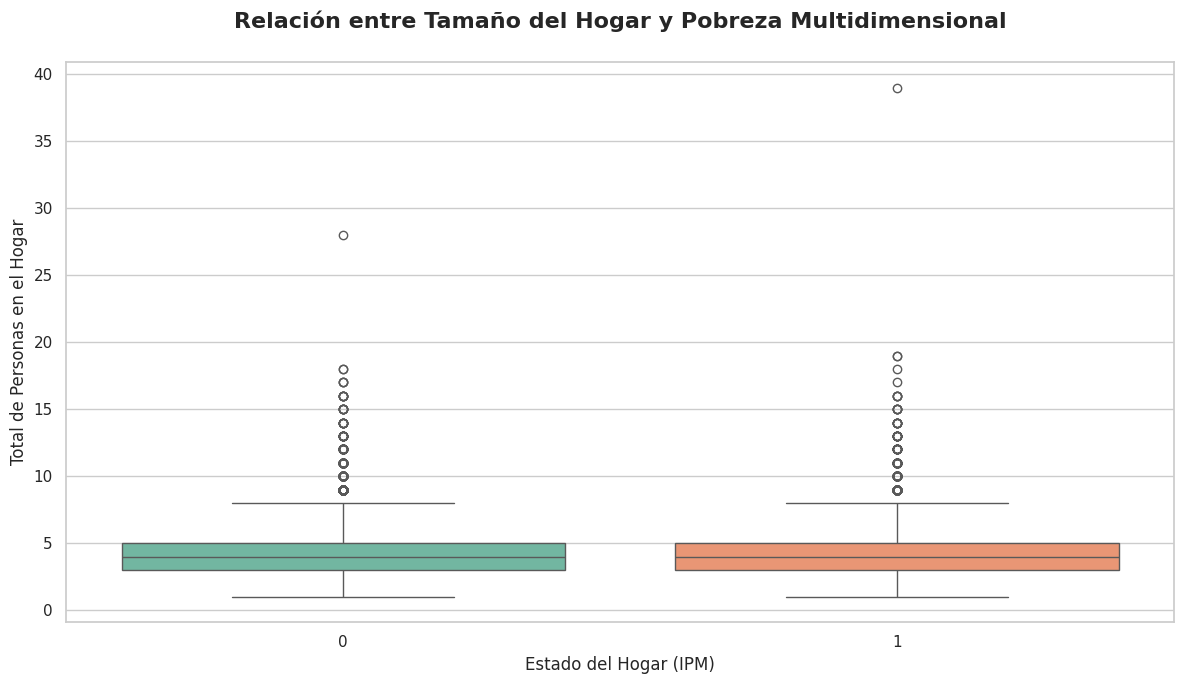

In [23]:
#Relacion tamaño del hogar
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# 2. Creación del Boxplot con etiquetas claras y colores
# Limitamos el eje Y a un valor razonable (ej. 15 personas) para ver mejor la caja,
# pero mencionamos los casos extremos en el texto.
ax = sns.boxplot(x='pobre_ipm', y='t_personas', data=df, palette='Set2', hue='pobre_ipm', legend=False)

# 3. Personalización de Títulos y Ejes
plt.title('Relación entre Tamaño del Hogar y Pobreza Multidimensional', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Estado del Hogar (IPM)', fontsize=12)
plt.ylabel('Total de Personas en el Hogar', fontsize=12)

# 4. Añadir una línea para el promedio
# Esto ayuda a ver si los hogares pobres son, en promedio, más grandes
for i, group in enumerate(['No Pobre', 'Pobre']):
    mean_val = df[df['pobre_ipm'] == group]['t_personas'].mean()
    plt.text(i, mean_val + 0.2, f'Promedio: {mean_val:.1f}',
             ha='center', va='bottom', color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_38410/991675151.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


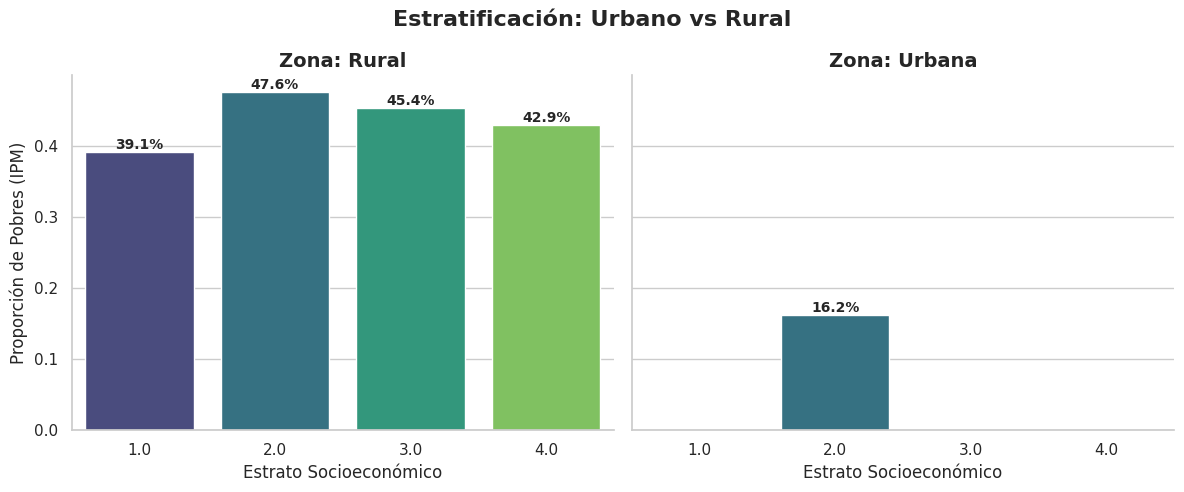

In [24]:
#Grafico de la relacion y diferenciación entre estrato y zona
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Usamos un FacetGrid (gráficas espejo) para comparar Urbano vs Rural
g = sns.catplot(
    data=df, x="estrato", y="pobre_ipm", col="zona_label",
    kind="bar", palette="viridis", height=5, aspect=1.2, errorbar=None
)

# 2. Ajustes estéticos de nivel profesional
g.set_axis_labels("Estrato Socioeconómico", "Proporción de Pobres (IPM)")
g.set_titles("Zona: {col_name}", size=14, fontweight='bold')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Estratificación: Urbano vs Rural', fontsize=16, fontweight='bold')

# 3. Añadir porcentajes sobre cada barra
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{100 * p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

Variables economicas

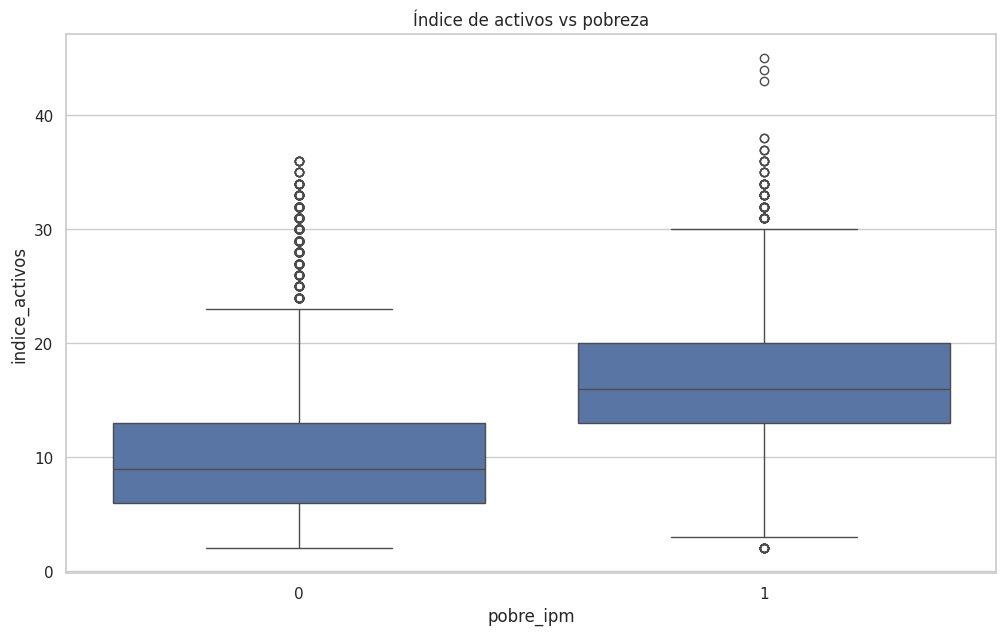

In [25]:
#Relacion entre los activos que poseen y la pobreza
plt.figure()
sns.boxplot(x='pobre_ipm', y='indice_activos', data=df)
plt.title('Índice de activos vs pobreza')
plt.show()

/tmp/ipykernel_38410/3528459149.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


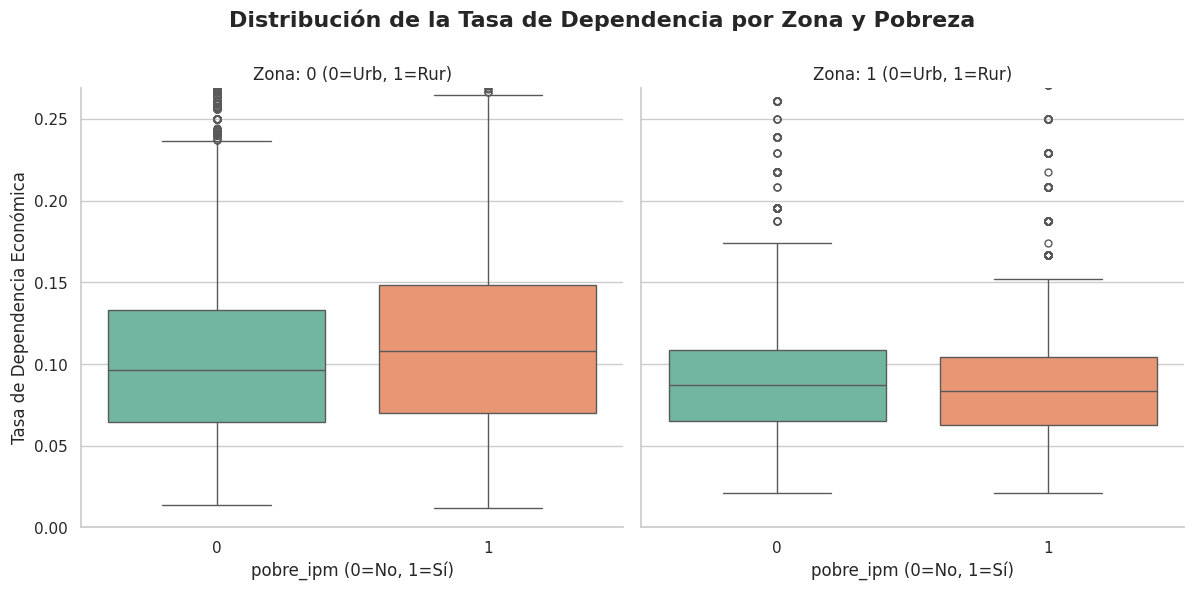

In [26]:
#Realciuon tasa dependencia por zona
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo limpia
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# 2. Creamos el Boxplot (Es la mejor forma de ver una tasa o número)
# x = Pobreza, y = La tasa de dependencia, col = Zona
g = sns.catplot(
    data=df,
    x='pobre_ipm',
    y='tasa_dependencia_proxy',
    col='zona',
    kind='box',
    palette='Set2',
    height=6,
    aspect=1
)

# 3. Etiquetas técnicas y claras
g.set_axis_labels("pobre_ipm (0=No, 1=Sí)", "Tasa de Dependencia Económica")
g.set_titles("Zona: {col_name} (0=Urb, 1=Rur)")

# 4. Ajuste para que los puntos extremos (outliers) no ensucien tanto
for ax in g.axes.flat:
    ax.set_ylim(0, df['tasa_dependencia_proxy'].quantile(0.99)) # Cortamos al 99% para ver mejor la caja

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribución de la Tasa de Dependencia por Zona y Pobreza', fontsize=16, fontweight='bold')

plt.show()

promedios por pobreza

In [27]:
df.groupby('pobre_ipm')[['t_personas','estrato','indice_activos','tasa_dependencia_proxy']].mean()

,t_personas,estrato,indice_activos,tasa_dependencia_proxy
pobre_ipm,,,,
0,4.42,2.00,10.46,0.10
1,4.48,2.05,16.85,0.10


probabilidad por zona

In [28]:
df.groupby('zona')['pobre_ipm'].mean()

,pobre_ipm
zona,
0,0.16
1,0.44


In [29]:
df.groupby(['zona','estrato'])['pobre_ipm'].mean()

zona  estrato
0     2.00      0.16
1     1.00      0.39
      2.00      0.48
      3.00      0.45
      4.00      0.43
Name: pobre_ipm, dtype: float64

In [30]:
df.groupby('zona')['estrato'].unique()

,estrato
zona,
0,[2.0]
1,"[2.0, 1.0, 3.0, 4.0]"


Probabilidad por region

In [31]:
df.groupby('region')['pobre_ipm'].mean().sort_values(ascending=False)

,pobre_ipm
region,
9.00,1.00
0.00,0.72
6.00,0.47
4.00,0.45
8.00,0.45
5.00,0.31
7.00,0.29
2.00,0.12
10.00,0.01


/tmp/ipykernel_38410/2313732349.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_plot, x='transicion_label', palette='viridis',


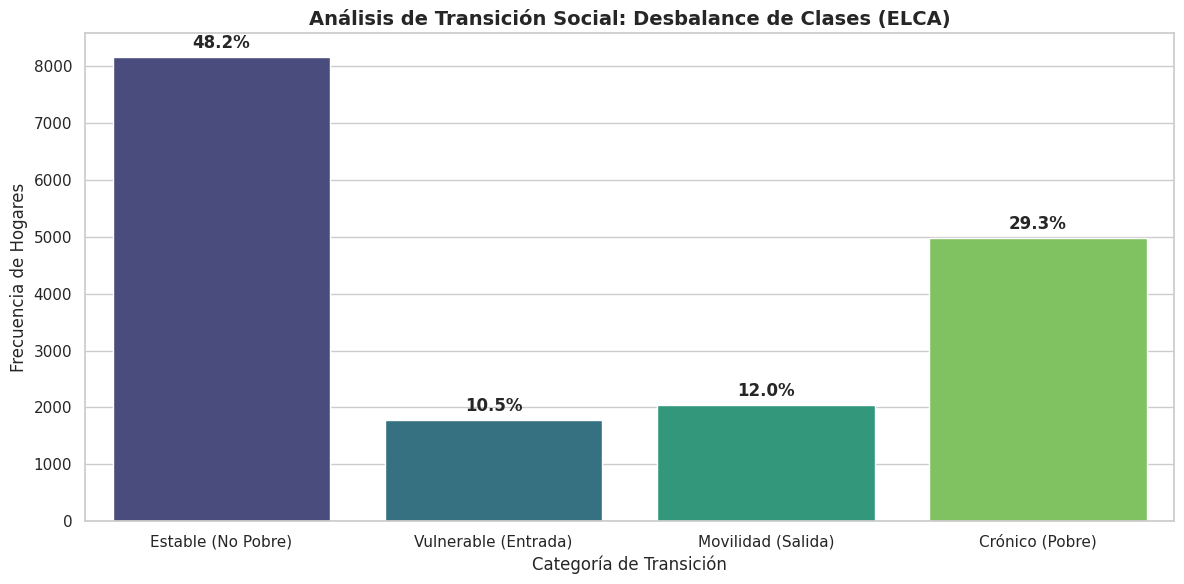

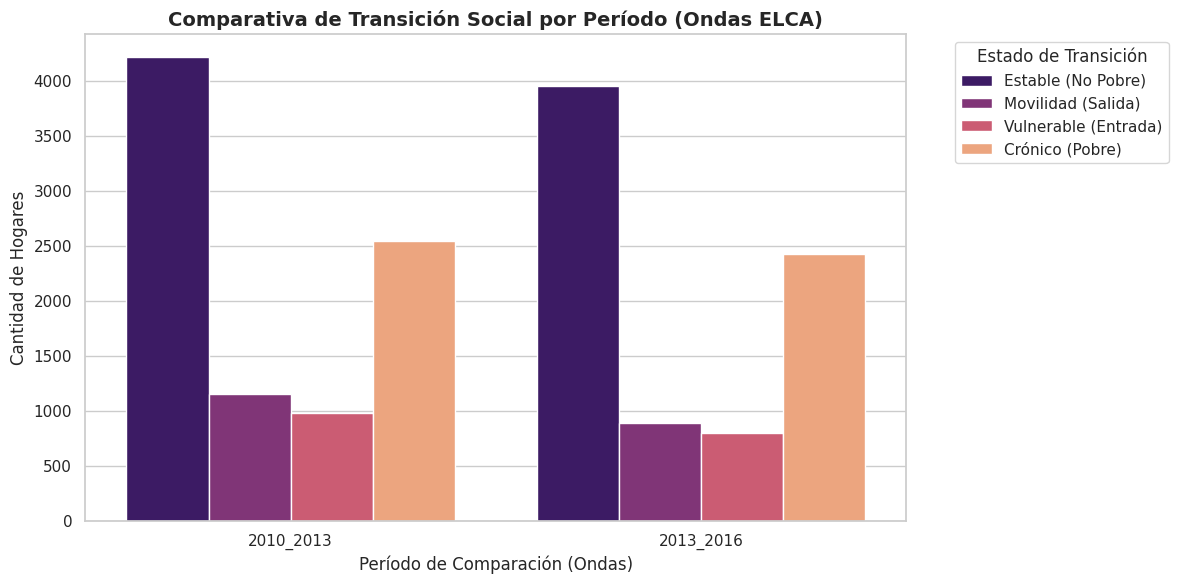

Matriz de Transición porcentual por período:
transicion     0     1     2     3
par_ondas                         
2010_2013  47.38 10.99 12.99 28.64
2013_2016  49.02  9.93 10.99 30.06


In [32]:
#Analisis de la transición

# 1. Definición de etiquetas para claridad visual
nombres_transicion = {
    0: 'Estable (No Pobre)',
    1: 'Vulnerable (Entrada)',
    2: 'Movilidad (Salida)',
    3: 'Crónico (Pobre)'
}

# Aplicamos las etiquetas al dataframe para la gráfica
df_plot = df.copy()
df_plot['transicion_label'] = df_plot['transicion'].map(nombres_transicion)

# --- GRÁFICA A: DESBALANCE DE CLASES  ---
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_plot, x='transicion_label', palette='viridis',
                   order=[nombres_transicion[i] for i in range(4)])

plt.title('Análisis de Transición Social: Desbalance de Clases (ELCA)', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Transición', fontsize=12)
plt.ylabel('Frecuencia de Hogares', fontsize=12)

# Añadir porcentajes sobre las barras
total = len(df_plot)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# --- GRÁFICA B: DINÁMICA TEMPORAL (COMPARATIVA POR ONDAS) ---
# Aquí analizamos si la vulnerabilidad cambió entre 2010-2013 y 2013-2016
plt.figure(figsize=(12, 6))
ax2 = sns.countplot(data=df_plot, x='par_ondas', hue='transicion_label', palette='magma')

plt.title('Comparativa de Transición Social por Período (Ondas ELCA)', fontsize=14, fontweight='bold')
plt.xlabel('Período de Comparación (Ondas)', fontsize=12)
plt.ylabel('Cantidad de Hogares', fontsize=12)
plt.legend(title='Estado de Transición', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- TABLA DE CONTINGENCIA (ANÁLISIS NO TRIVIAL) ---
# Esto te da los números exactos para tu documento de 1,500 palabras
tabla_ondas = pd.crosstab(df['par_ondas'], df['transicion'], normalize='index') * 100
print("Matriz de Transición porcentual por período:")
print(tabla_ondas.round(2))

In [33]:
# Configuración estética profesional (Punto 7 y 10 de la rúbrica)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Diccionarios de etiquetas para claridad visual (David López)
nombres_pobreza = {0: 'No Pobre', 1: 'Pobre'}
nombres_zona = {0: 'Urbana', 1: 'Rural'}
# Asumiendo códigos de región ELCA estándar, ajústalos si son diferentes
nombres_region = {1: 'Pacífica', 2: 'Atlántica', 3: 'Central', 4: 'Andina', 5: 'Amazonía/Orinoquía'}

# Aplicamos etiquetas a una copia para no alterar el df original de modelado
df_plot = df.copy()
df_plot['pobre_label'] = df_plot['pobre_ipm'].map(nombres_pobreza)
df_plot['zona_label'] = df_plot['zona'].map(nombres_zona)
df_plot['region_label'] = df_plot['region'].map(nombres_region)

In [36]:
df_plot[['ipm_sintetico','pobre_label','par_ondas']].head()

,ipm_sintetico,pobre_label,par_ondas
0,0.00,No Pobre,2010_2013
1,0.00,No Pobre,2010_2013
2,0.00,No Pobre,2010_2013
3,0.00,No Pobre,2010_2013
4,0.00,No Pobre,2010_2013


In [37]:
df_plot.groupby('par_ondas')['ipm_sintetico'].mean()

,ipm_sintetico
par_ondas,
2010_2013,0.06
2013_2016,0.31


In [38]:
# Valores únicos (para ver si está discretizado)
df_plot['ipm_sintetico'].unique()

array([0. , 0.2, 0.4, 0.6, 0.8])

scatter clasico

/tmp/ipykernel_38410/1048629828.py:6: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.scatterplot(


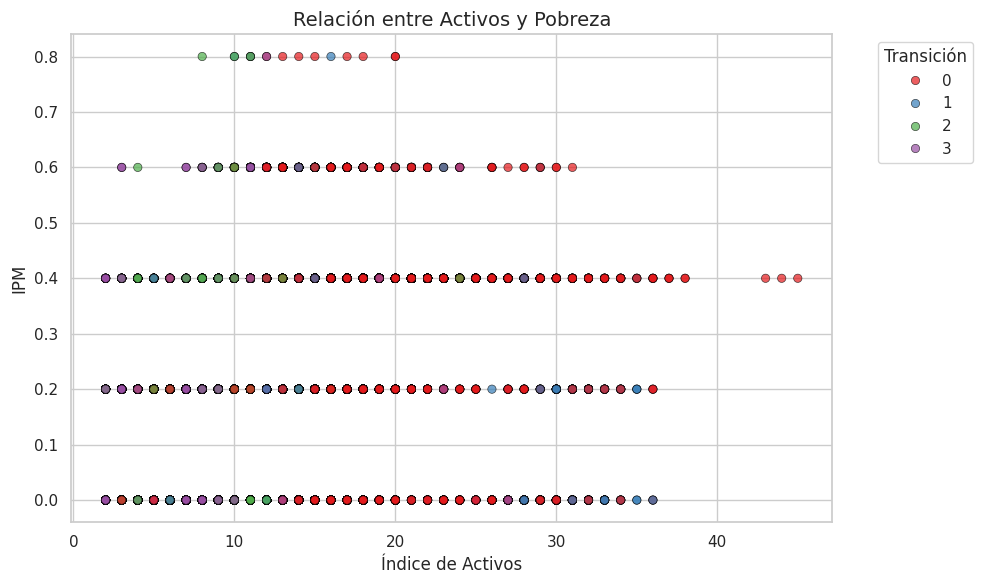

In [39]:
plt.figure(figsize=(10, 6))


palette = sns.color_palette("Set1")

sns.scatterplot(
    x='indice_activos',
    y='ipm_sintetico',
    hue='transicion',
    data=df,
    alpha=0.7,
    palette=palette,
    edgecolor='black'
)

plt.title('Relación entre Activos y Pobreza')
plt.xlabel('Índice de Activos')
plt.ylabel('IPM')

plt.legend(title='Transición', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


Grafico burbuja



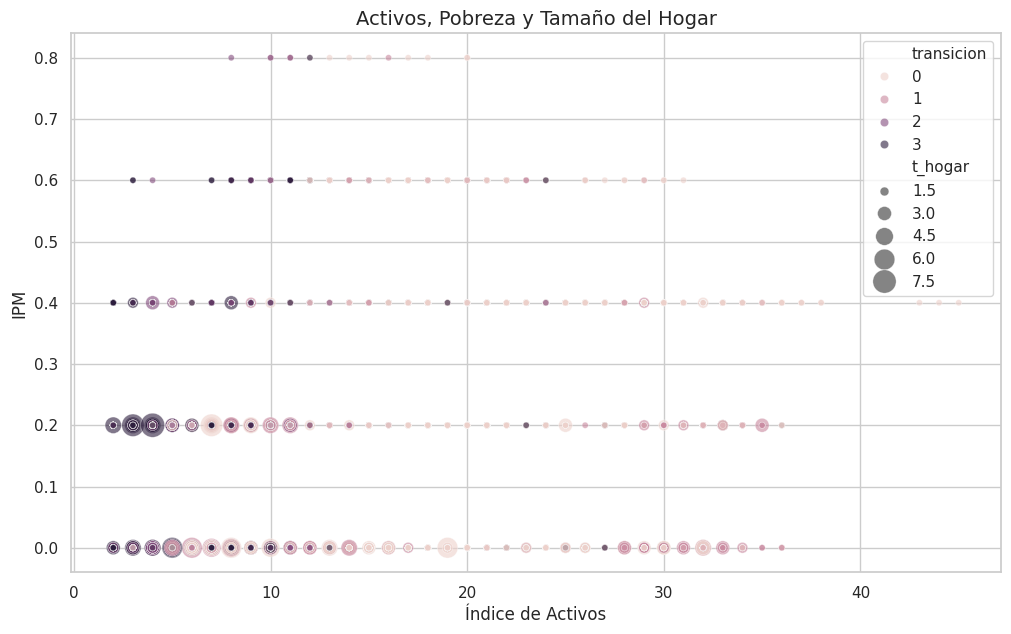

In [40]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='indice_activos',
    y='ipm_sintetico',
    size='t_hogar',
    hue='transicion',
    data=df,
    sizes=(20, 300),
    alpha=0.6
)

plt.title('Activos, Pobreza y Tamaño del Hogar')
plt.xlabel('Índice de Activos')
plt.ylabel('IPM')
plt.show()

**grafico** de lineas

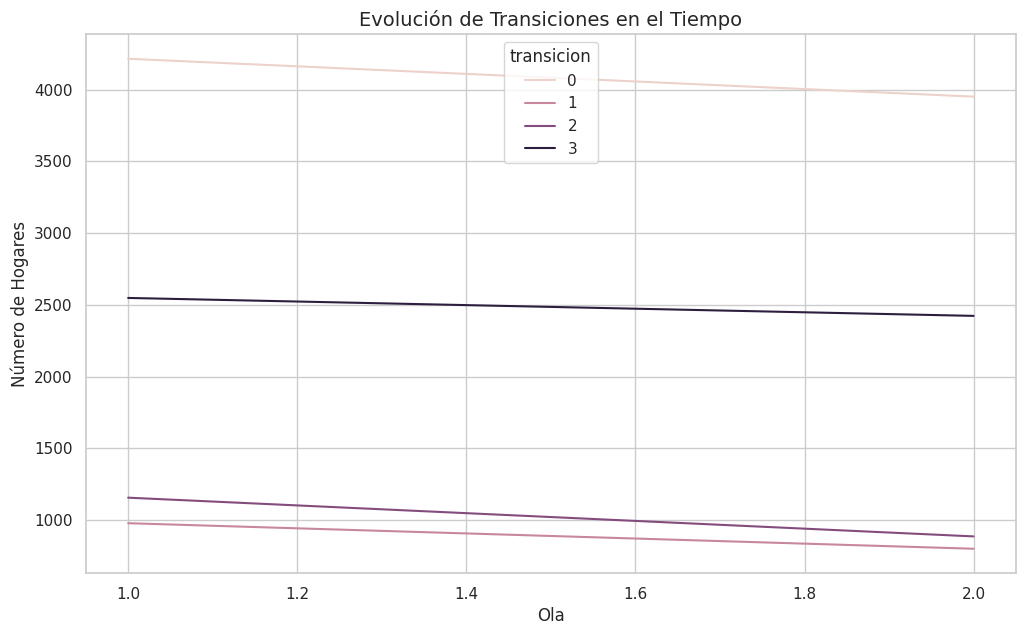

In [41]:
transicion_tiempo = df.groupby(['ola', 'transicion']).size().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(
    x='ola',
    y=0,
    hue='transicion',
    data=transicion_tiempo
)

plt.title('Evolución de Transiciones en el Tiempo')
plt.xlabel('Ola')
plt.ylabel('Número de Hogares')
plt.show()

barras apiladas

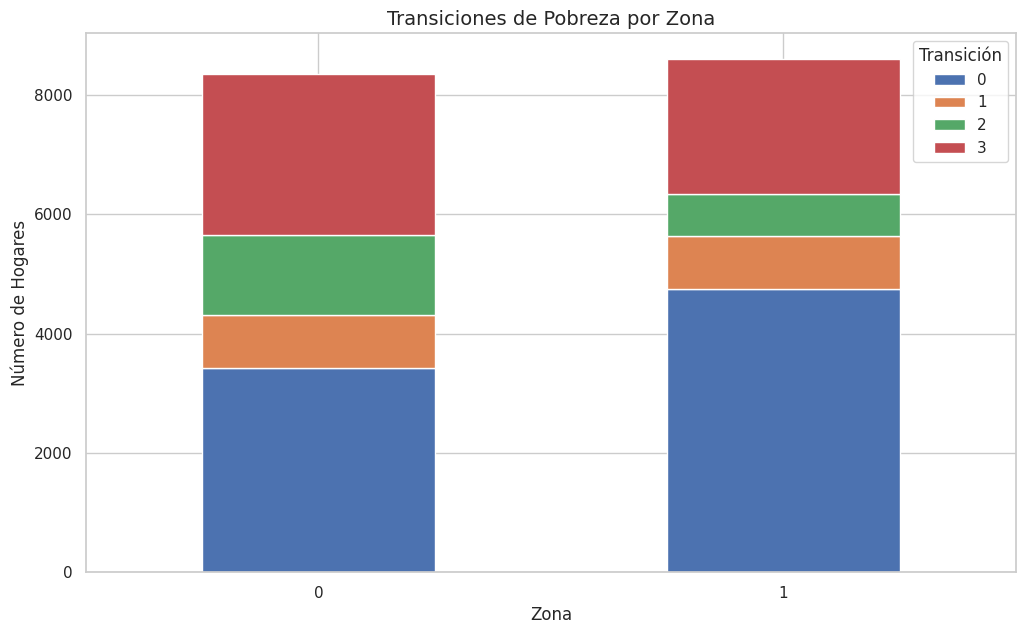

In [42]:
transiciones_zona = df.groupby(['zona', 'transicion']).size().unstack()

transiciones_zona.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title('Transiciones de Pobreza por Zona')
plt.xlabel('Zona')
plt.ylabel('Número de Hogares')
plt.xticks(rotation=0)
plt.legend(title='Transición')
plt.show()

matriz correlacion

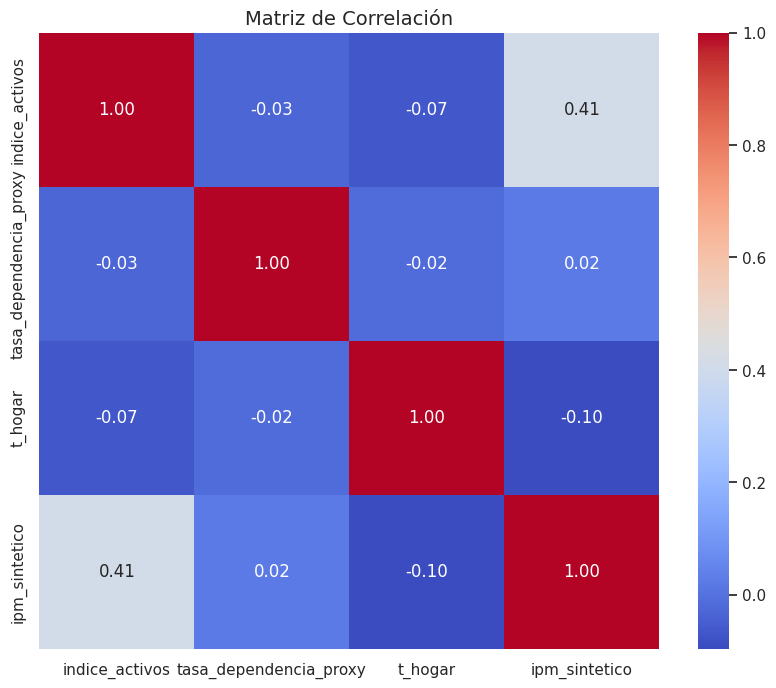

In [43]:
df_numeric = df[[
    'indice_activos',
    'tasa_dependencia_proxy',
    't_hogar',
    'ipm_sintetico'
]]

correlation_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

pairplot

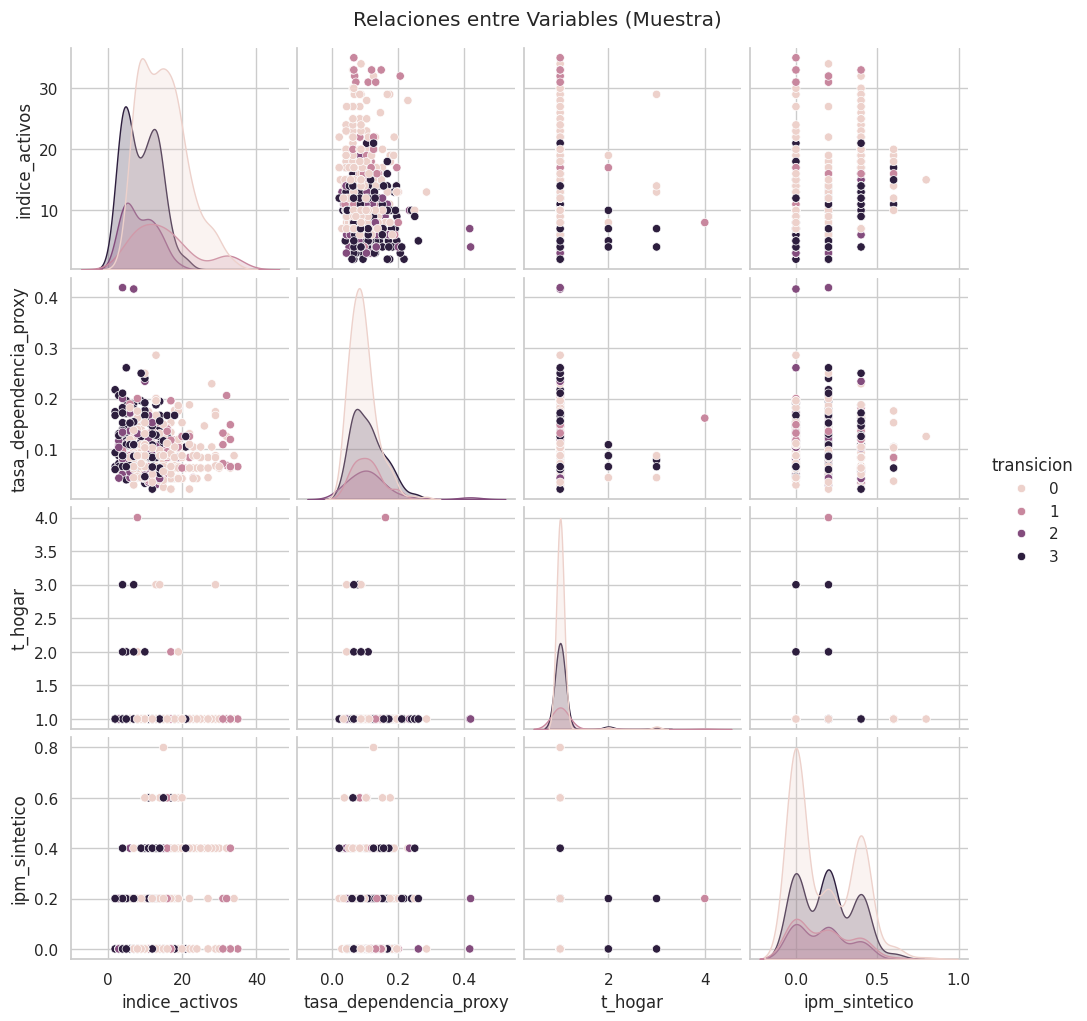

In [44]:
df_sample = df.sample(500)

sns.pairplot(
    df_sample[[
        'indice_activos',
        'tasa_dependencia_proxy',
        't_hogar',
        'ipm_sintetico',
        'transicion' # Added 'transicion' to the list of columns
    ]],
    hue='transicion',
    diag_kind='kde'
)

plt.suptitle('Relaciones entre Variables (Muestra)', y=1.02)
plt.show()

JOINT PLOT

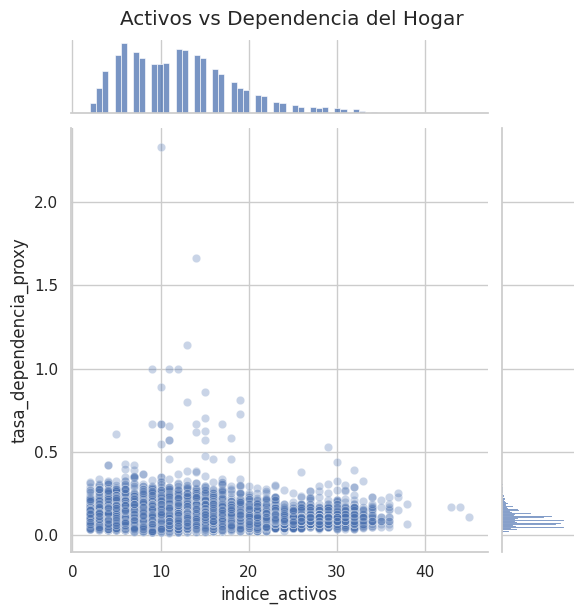

In [45]:
sns.jointplot(
    x='indice_activos',
    y='tasa_dependencia_proxy',
    data=df,
    alpha=0.3
)

plt.suptitle('Activos vs Dependencia del Hogar', y=1.02)
plt.show()

violin plot

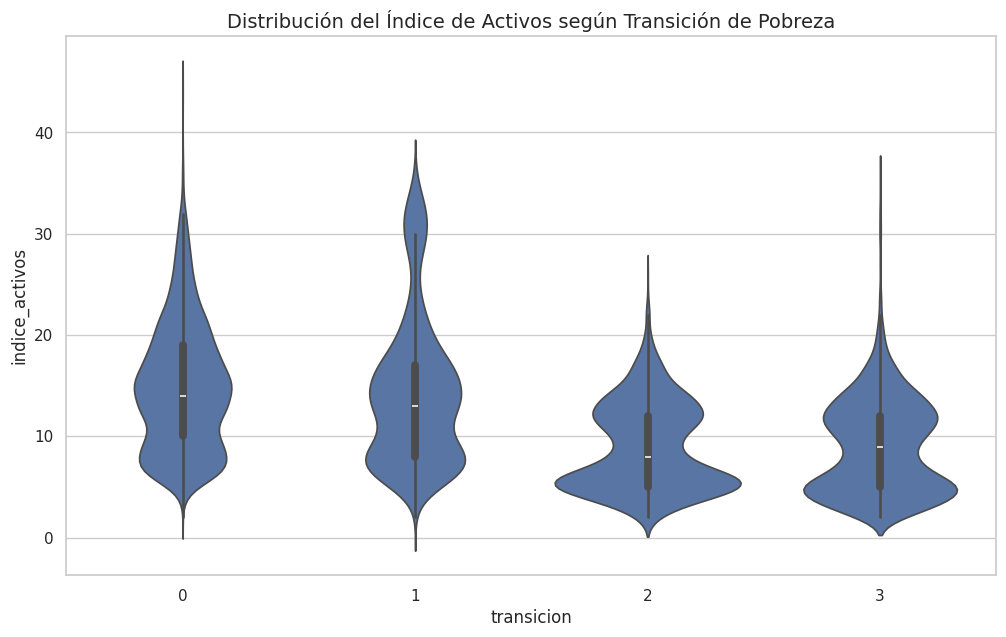

In [46]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='transicion', y='indice_activos', data=df)
plt.title('Distribución del Índice de Activos según Transición de Pobreza')
plt.show()

Los analisis realizados para las graficas están en el documento de word